In [1]:
#for STD fib gel 
gauss_thres = 0.25
min_size = 200
hole_size=150
dist=100
sigma=0.5
savedir = './intermediate_files/'
#for norha 

In [2]:
from matplotlib import pyplot as plt 

from tifffile import imread, imwrite
import numpy as np
from skimage import filters, morphology, measure
from joblib import Parallel, delayed

import warnings 
warnings.filterwarnings('ignore')


In [3]:
def import_imgs(filepath, sigma, gauss_thres, *channel, verbose=True):
    if channel:
        img = imread(filepath)[:,:,channel[0]]
    else:
        img=imread(filepath)
    img=filters.gaussian(img, sigma=sigma)
    img[img<gauss_thres]=0
    img[img>=gauss_thres]=1
    if verbose:
        plt.imshow(img)
        imwrite(savedir + 'binarized/' + filepath[:-4] + '.tif', img)

    return img


def process_img(img, min_size, hole_size, verbose=True):
    objects = measure.label(img)
    large_obj = morphology.remove_small_objects(objects, min_size=min_size)


    large_obj[large_obj>0]=1 

    clean_img=morphology.remove_small_holes(large_obj, area_threshold=hole_size)
    if verbose:
        plt.imshow(clean_img)
        imwrite(savedir + 'processed/' + filepath[:-4] + '.tif', clean_img)
    return clean_img

def get_thickness(clean_img, dist):
    skel=morphology.skeletonize(clean_img)
    imwrite(savedir + 'skeletonized/' + filepath[:-4] + '.tif', skel)
    edge = filters.sobel(clean_img)
    imwrite(savedir + 'edged/' + filepath[:-4] + '.tif', edge)
    x_ind, y_ind=np.where(skel)

    def myfun(i):
        point=[x_ind[i], y_ind[i]]
        xmin=max(point[0]-dist, 0)
        ymin=max(point[1]-dist, 0)
        xmax = min(point[0]+dist+1, clean_img.shape[0])
        ymax= min(point[1]+dist+1, clean_img.shape[1])
        subimg = edge[xmin:xmax, ymin:ymax]
        x,y=np.where(subimg>0)
        x=x-dist
        y=y-dist
        d=np.sqrt(x**2 + y**2)
        return int(d.min())

    n = Parallel(n_jobs=-1)(delayed(myfun)(i) for i in range(x_ind.shape[0]))
    return np.asarray(n)


In [13]:
import os
filelist = [i for i in os.listdir() if i.endswith('.tif')]

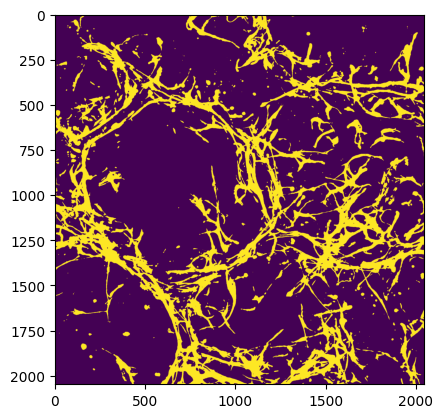

In [67]:
filepath = 'nor4.tif'
img = import_imgs(filepath, sigma, gauss_thres, 0, verbose=True)


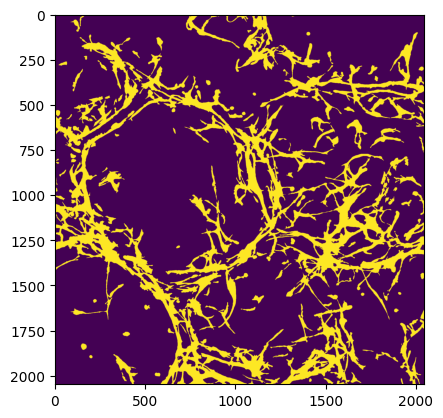

In [68]:
clean_img = process_img(img, min_size, hole_size)
x1 = get_thickness(clean_img, dist)
np.savetxt(filepath[:-4] + '.csv', x1)

6.681234019647423


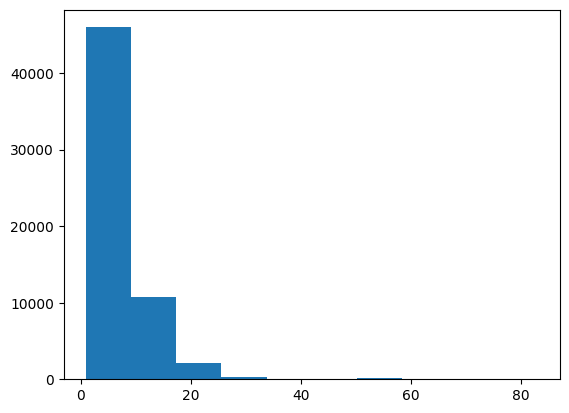

In [69]:
plt.hist(x1[x1>0])
print(x1[x1>0].mean())